In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
malr_file = "D:/5.2/Project/Data/gsp_cov_2020/gsp_cov_2020.shp"
gdf = gpd.read_file(malr_file)
gdf.to_csv('malaria.csv')

In [3]:
list(gdf.columns)

['DHSID',
 'DHSCC',
 'DHSYEAR',
 'DHSCLUST',
 'CCFIPS',
 'ADM1FIPS',
 'ADM1FIPSNA',
 'ADM1SALBNA',
 'ADM1SALBCO',
 'ADM1DHS',
 'ADM1NAME',
 'DHSREGCO',
 'DHSREGNA',
 'SOURCE',
 'URBAN_RURA',
 'LATNUM',
 'LONGNUM',
 'ALT_GPS',
 'ALT_DEM',
 'DATUM',
 'DHSID_1',
 'GPS_Datase',
 'DHSCC_1',
 'DHSYEAR_1',
 'DHSCLUST_1',
 'SurveyID',
 'pop2000',
 'pop2005',
 'pop2010',
 'pop2015',
 'pop2020',
 'arid_02',
 'arid_05',
 'arid_10',
 'arid_15',
 'arid_20',
 'DLST_00',
 'DLST_05',
 'DLST_10',
 'DLST_15',
 'DLST_20',
 'DTemp00',
 'DTemp05',
 'DTemp10',
 'DTemp15',
 'DTemp20',
 'Elev',
 'EVI00',
 'EVI05',
 'EVI10',
 'EVI15',
 'EVI20',
 'FD_00',
 'FD_05',
 'FD_10',
 'FD_15',
 'FD_20',
 'Global_Hum',
 'Growing_Se',
 'Irrigation',
 'ITN_00',
 'ITN_05',
 'ITN_10',
 'ITN_15',
 'ITN_20',
 'LST_00',
 'LST_05',
 'LST_10',
 'LST_15',
 'LST_20',
 'Livestock_',
 'Livestock1',
 'Livestoc_1',
 'Livestoc_2',
 'Livestoc_3',
 'MI_00',
 'MI_05',
 'MI_10',
 'MI_15',
 'MI_20',
 'MP_00',
 'MP_05',
 'MP_10',
 'MP_15',
 '

In [5]:
# create 
gdf_num = gdf.select_dtypes(include=['number'])

In [6]:
# Compute Pearson correlation
correlation_matrix = gdf_num.corr(method='pearson')

# Print correlation values
print(correlation_matrix)


          DHSYEAR  DHSCLUST   ADM1DHS  DHSREGCO    LATNUM   LONGNUM  ALT_GPS  \
DHSYEAR       NaN       NaN       NaN       NaN       NaN       NaN      NaN   
DHSCLUST      NaN  1.000000 -0.271069 -0.271069  0.217824 -0.417609      NaN   
ADM1DHS       NaN -0.271069  1.000000  1.000000 -0.114030  0.588405      NaN   
DHSREGCO      NaN -0.271069  1.000000  1.000000 -0.114030  0.588405      NaN   
LATNUM        NaN  0.217824 -0.114030 -0.114030  1.000000 -0.423539      NaN   
...           ...       ...       ...       ...       ...       ...      ...   
WD_00         NaN  0.393254 -0.722270 -0.722270  0.080796 -0.836981      NaN   
WD_05         NaN  0.423173 -0.695080 -0.695080  0.202745 -0.829754      NaN   
WD_10         NaN  0.405258 -0.693318 -0.693318  0.263844 -0.916863      NaN   
WD_15         NaN  0.268733 -0.428761 -0.428761  0.023258 -0.738558      NaN   
WD_20         NaN  0.359814 -0.657012 -0.657012  0.187130 -0.882894      NaN   

           ALT_DEM  DHSYEAR_1  DHSCLUST

Top 10 Correlations:
WD_05  DHSYEAR_1   NaN
       WD_05       NaN
       WD_10       NaN
       WD_15       NaN
       WD_20       NaN
WD_10  DHSYEAR     NaN
       ALT_GPS     NaN
       DHSYEAR_1   NaN
       WD_10       NaN
       WD_15       NaN
       WD_20       NaN
WD_15  DHSYEAR     NaN
       ALT_GPS     NaN
       DHSYEAR_1   NaN
       WD_15       NaN
       WD_20       NaN
WD_20  DHSYEAR     NaN
       ALT_GPS     NaN
       DHSYEAR_1   NaN
       WD_20       NaN
dtype: float64


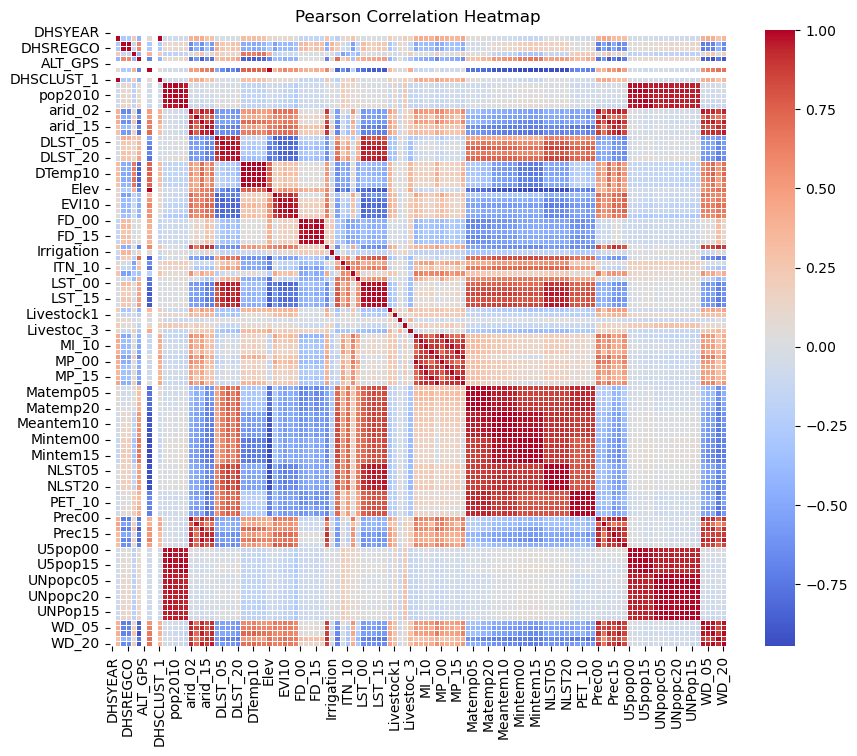

In [7]:
# Remove self-correlations (diagonal) and get top 10 correlations
corr_unstacked = correlation_matrix.where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool)).unstack()
top_10_corr = corr_unstacked.abs().sort_values(ascending=False).tail(20)

# Print top 10 correlations
print("Top 10 Correlations:")
print(top_10_corr)

# Plot heatmap without annotations
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, cmap="coolwarm", linewidths=0.5, square=True)
plt.title("Pearson Correlation Heatmap")
plt.show()

In [13]:
import geopandas as gpd
import re
import os

# Load your GeoDataFrame
# gdf = gpd.read_file("your_file_path.shp")

# Base columns to always include
base_columns = [
    'DHSID', 'DHSCC', 'DHSYEAR', 'DHSCLUST', 'CCFIPS', 'ADM1FIPS', 'ADM1FIPSNA',
    'ADM1SALBNA', 'ADM1SALBCO', 'ADM1DHS', 'ADM1NAME', 'DHSREGCO', 'DHSREGNA',
    'SOURCE', 'URBAN_RURA', 'LATNUM', 'LONGNUM', 'ALT_GPS', 'ALT_DEM', 'DATUM',
    'geometry'
]

# Target years
target_years = ['2000', '2005', '2010', '2015', '2020']

# Create a directory to save the shapefiles
output_dir = "shapefiles_by_year"
os.makedirs(output_dir, exist_ok=True)

for year in target_years:
    short = year[-2:]  # last two digits
    year_cols = [
        col for col in gdf.columns
        if re.search(rf'(_)?{short}$', col) or col.endswith(year)
    ]
    selected_cols = list(set(base_columns + year_cols))
    year_gdf = gdf[selected_cols]

    # Save to shapefile
    output_path = os.path.join(output_dir, f"data_{year}.shp")
    year_gdf.to_file(output_path)
    print(f"✅ Shapefile for {year} saved: {output_path}")


✅ Shapefile for 2000 saved: shapefiles_by_year\data_2000.shp
✅ Shapefile for 2005 saved: shapefiles_by_year\data_2005.shp
✅ Shapefile for 2010 saved: shapefiles_by_year\data_2010.shp
✅ Shapefile for 2015 saved: shapefiles_by_year\data_2015.shp
✅ Shapefile for 2020 saved: shapefiles_by_year\data_2020.shp


In [23]:
gdf_2 = gpd.read_file('./annual_gdf_2.gpkg')
gdf_num = gdf_2.select_dtypes(include=['number'])
# Compute Pearson correlation
correlation_matrix = gdf_num.corr(method='pearson')

# Print correlation values
print(correlation_matrix)

               Slope  ALT_GPS   ALT_DEM  All_Popu_2  Annual_P_2  BUILT_Po_2  \
Slope       1.000000      NaN  0.450556   -0.017014    0.159356   -0.121759   
ALT_GPS          NaN      NaN       NaN         NaN         NaN         NaN   
ALT_DEM     0.450556      NaN  1.000000    0.231592    0.361856   -0.201946   
All_Popu_2 -0.017014      NaN  0.231592    1.000000   -0.035323    0.060088   
Annual_P_2  0.159356      NaN  0.361856   -0.035323    1.000000   -0.412831   
BUILT_Po_2 -0.121759      NaN -0.201946    0.060088   -0.412831    1.000000   
Day_Land_2  0.083389      NaN  0.203920   -0.001621    0.250995   -0.356556   
Diurnal__2  0.158455      NaN  0.353892   -0.042503    0.999870   -0.411540   
Enhanced_2  0.131698      NaN  0.454368    0.247160    0.225073   -0.380953   
Frost_Da_2  0.158283      NaN  0.353427   -0.042670    0.999862   -0.411504   
ITN_Cove_2 -0.198275      NaN -0.099340    0.113241    0.151420   -0.490431   
Land_Sur_2  0.083371      NaN  0.203442   -0.001527 

In [28]:
list(gdf_2.columns)

['Slope',
 'ALT_GPS',
 'ALT_DEM',
 'All_Popu_2',
 'Annual_P_2',
 'BUILT_Po_2',
 'Day_Land_2',
 'Diurnal__2',
 'Enhanced_2',
 'Frost_Da_2',
 'ITN_Cove_2',
 'Land_Sur_2',
 'Livestoc_2',
 'Malaria__2',
 'Maximum__2',
 'Mean_Tem_2',
 'Minimum__2',
 'Night_La_2',
 'Rainfall_2',
 'SMOD_Pop_2',
 'Temperat_2',
 'U5_Popul_2',
 'UN_Popul_2',
 'Wet_Days_2',
 'geometry']

Top 10 Correlations:


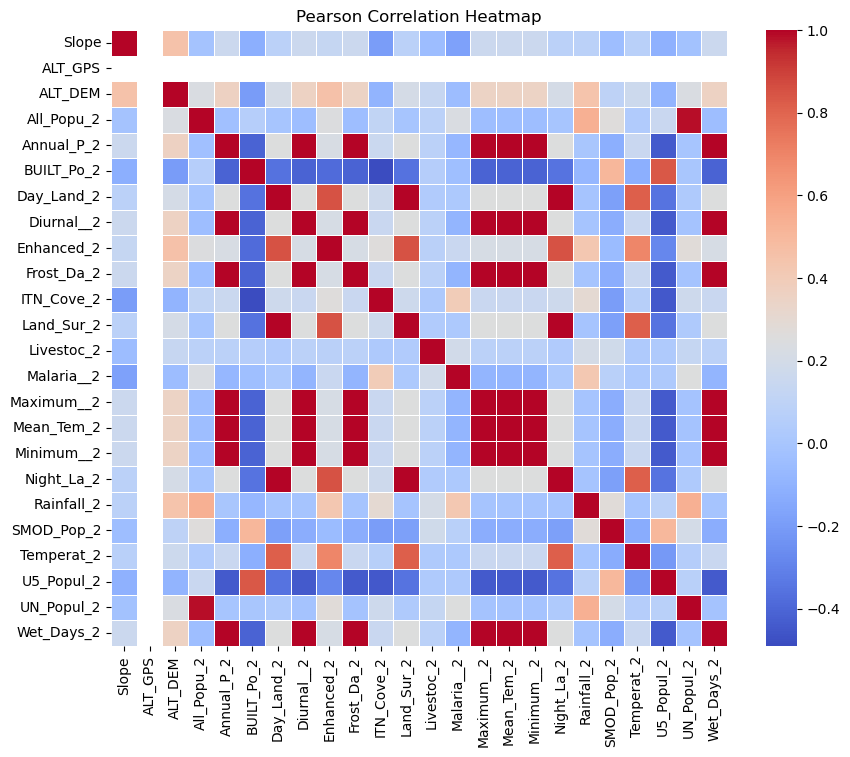

In [24]:
print("Top 10 Correlations:")
# print(top_10_corr)

# Plot heatmap without annotations
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, cmap="coolwarm", linewidths=0.5, square=True)
plt.title("Pearson Correlation Heatmap")
plt.show()

C:\Users\user\AppData\Local\Temp\ipykernel_2656\1076458228.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=correlations.values, y=correlations.index, palette="coolwarm_r")


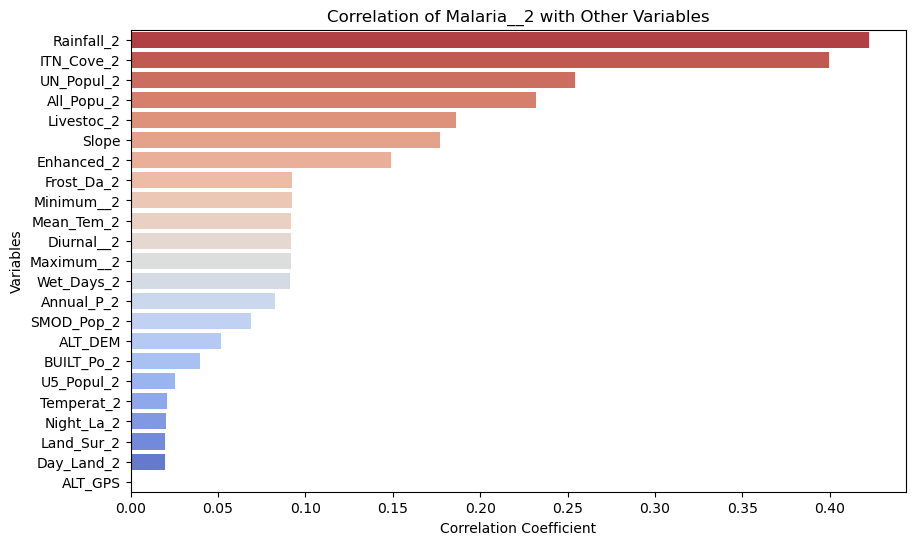

In [26]:
# 🏆 2️⃣ Correlation of a Single Variable vs. All Others
target_variable = "Malaria__2"  # Change to the variable you want to analyze

# Extract correlations of the target variable
correlations = correlation_matrix[target_variable].drop(target_variable)  # Remove self-correlation

# Sort by absolute value (strongest correlations first)
correlations = correlations.abs().sort_values(ascending=False)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x=correlations.values, y=correlations.index, palette="coolwarm_r")
plt.xlabel("Correlation Coefficient")
plt.ylabel("Variables")
plt.title(f"Correlation of {target_variable} with Other Variables")
plt.show()

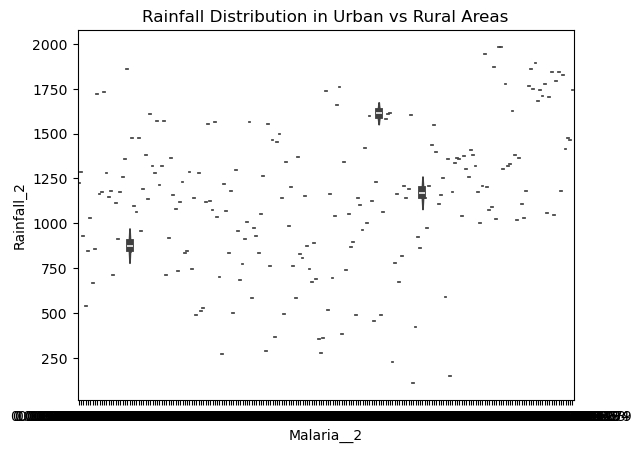

In [27]:
sns.violinplot(data=gdf, x="Malaria__2", y="Rainfall_2")
plt.title("Rainfall Distribution in Urban vs Rural Areas")
plt.show()


C:\Users\user\AppData\Local\Temp\ipykernel_2656\3854957935.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_corr.values, y=top_10_corr.index, palette="coolwarm_r")


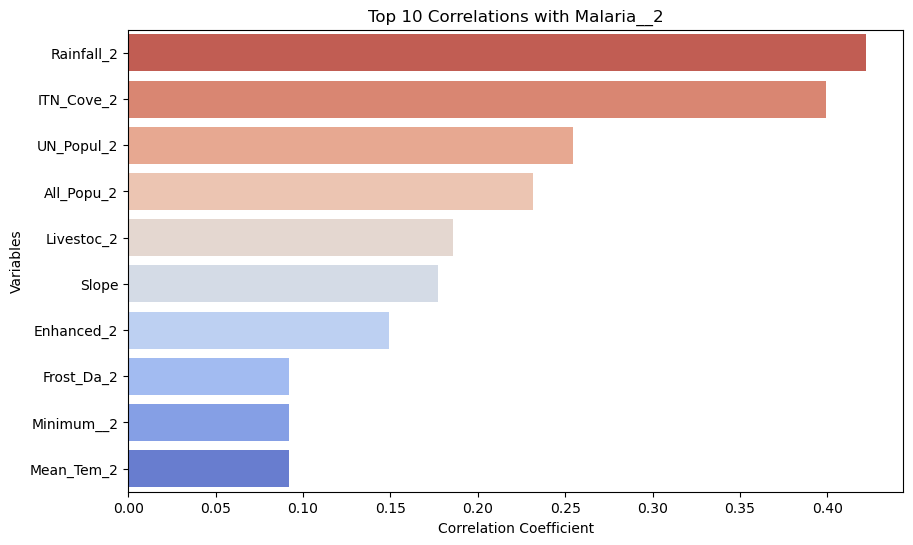

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select numerical variables
gdf_numeric = gdf_2.select_dtypes(include=['number'])

# Compute correlation matrix
correlation_matrix = gdf_numeric.corr()

# Extract correlations with Malaria__2
malaria_corr = correlation_matrix["Malaria__2"].drop("Malaria__2")

# Get the top 10 strongest correlations
top_10_corr = malaria_corr.abs().sort_values(ascending=False).head(10)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x=top_10_corr.values, y=top_10_corr.index, palette="coolwarm_r")
plt.xlabel("Correlation Coefficient")
plt.ylabel("Variables")
plt.title("Top 10 Correlations with Malaria__2")
plt.show()


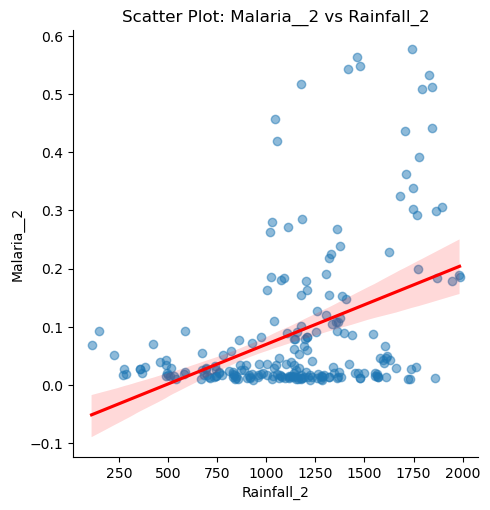

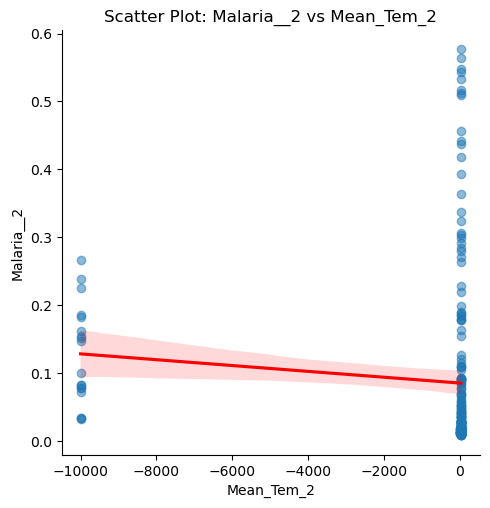

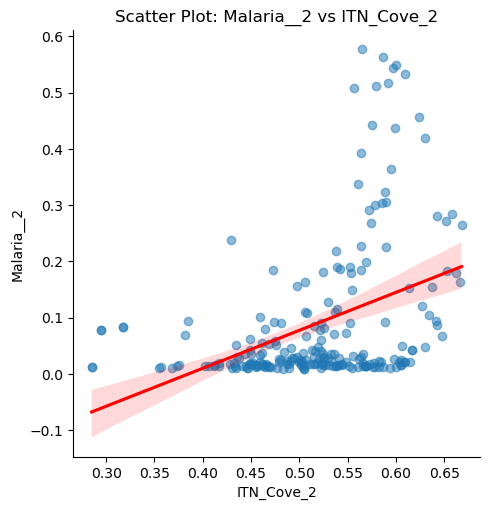

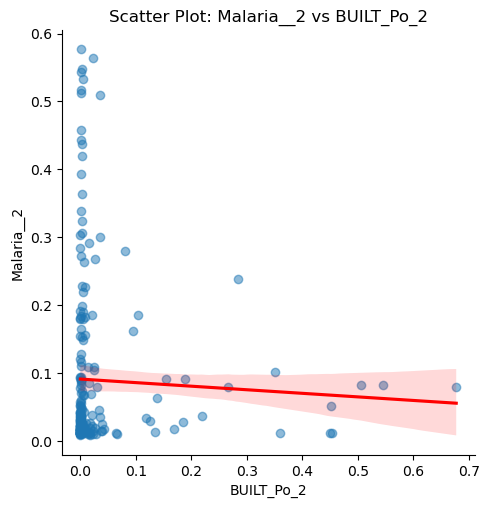

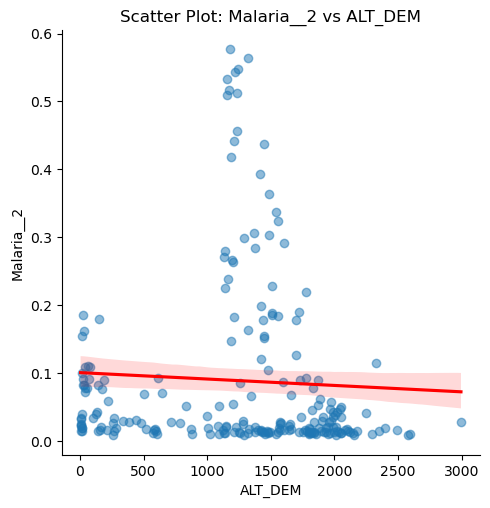

In [30]:
important_vars = ["Rainfall_2", "Mean_Tem_2", "ITN_Cove_2", "BUILT_Po_2", "ALT_DEM"]

for var in important_vars:
    sns.lmplot(data=gdf_2, x=var, y="Malaria__2", scatter_kws={"alpha":0.5}, line_kws={"color": "red"})
    plt.title(f"Scatter Plot: Malaria__2 vs {var}")
    plt.show()


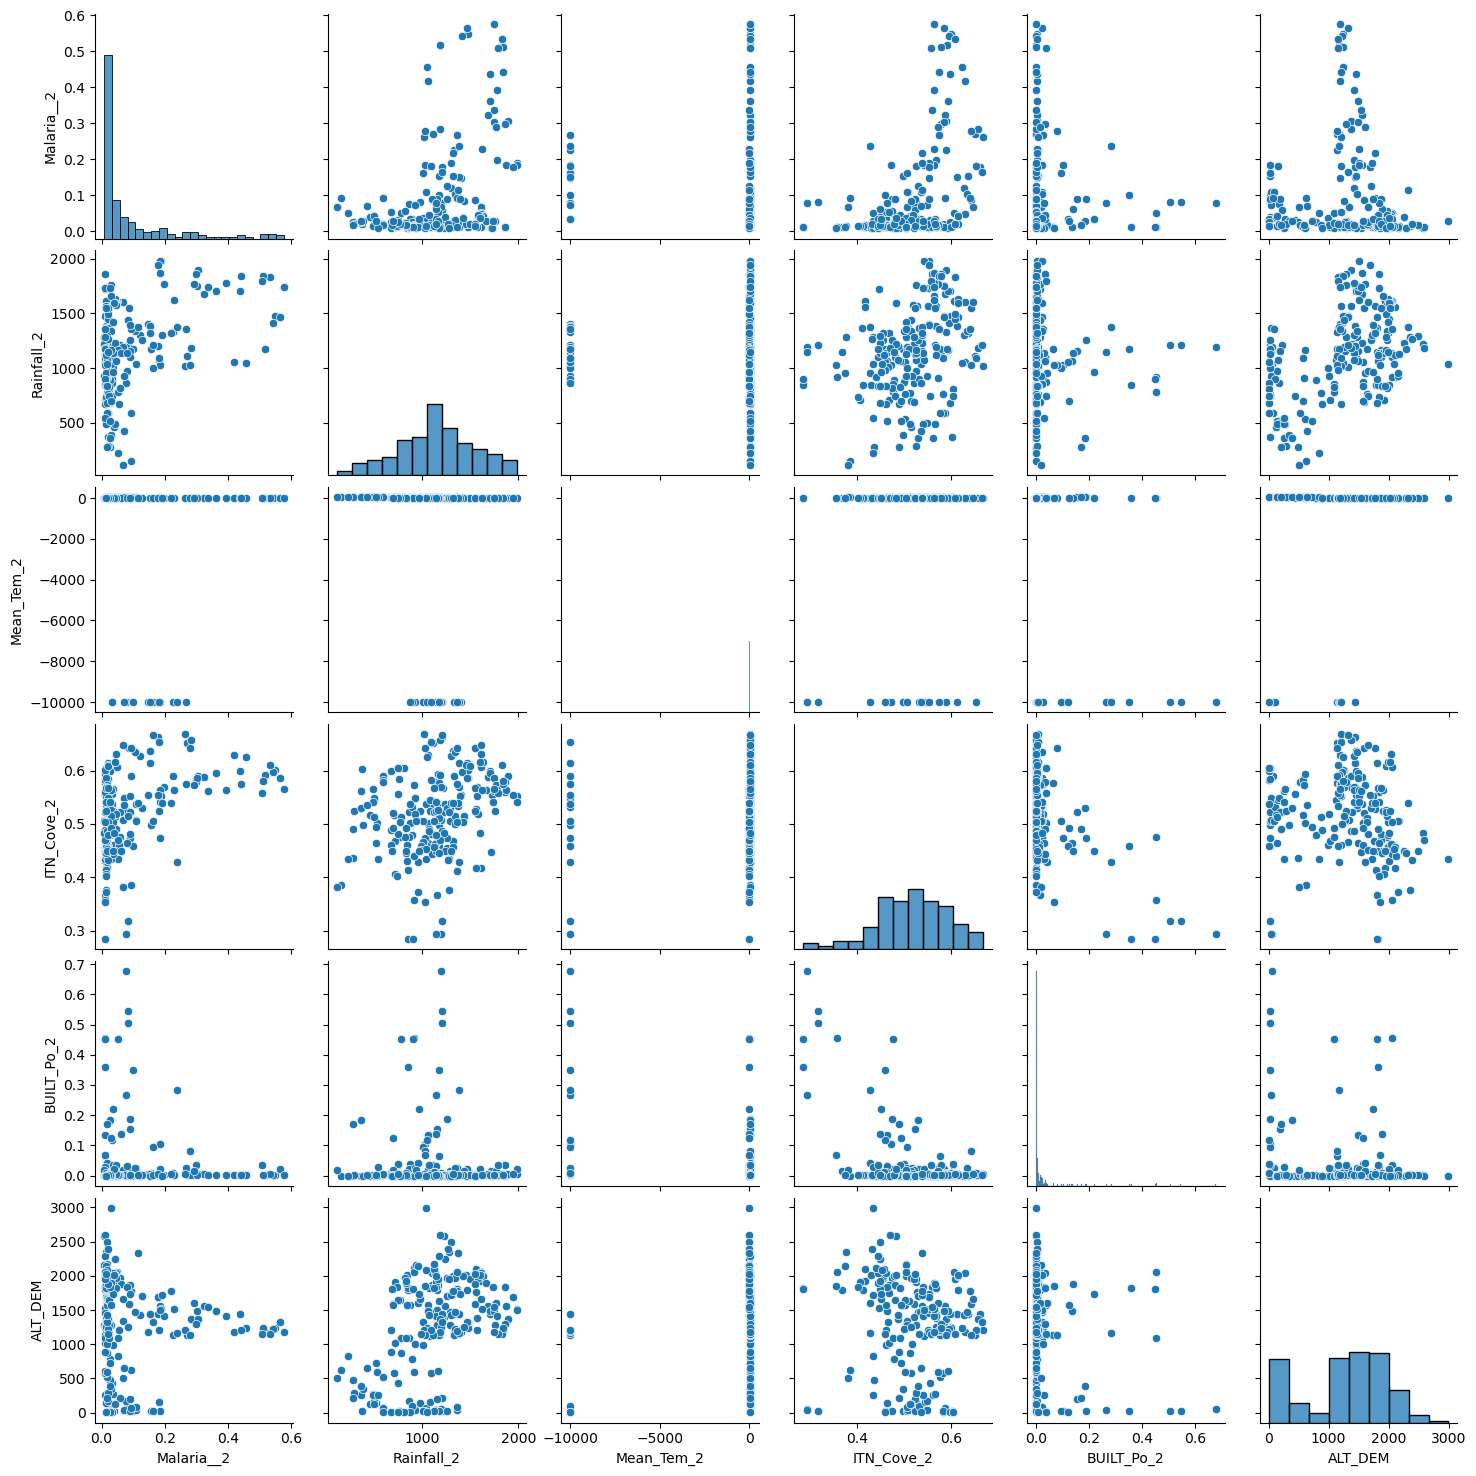

In [31]:
selected_columns = ["Malaria__2", "Rainfall_2", "Mean_Tem_2", "ITN_Cove_2", "BUILT_Po_2", "ALT_DEM"]
sns.pairplot(gdf_2[selected_columns])
plt.show()


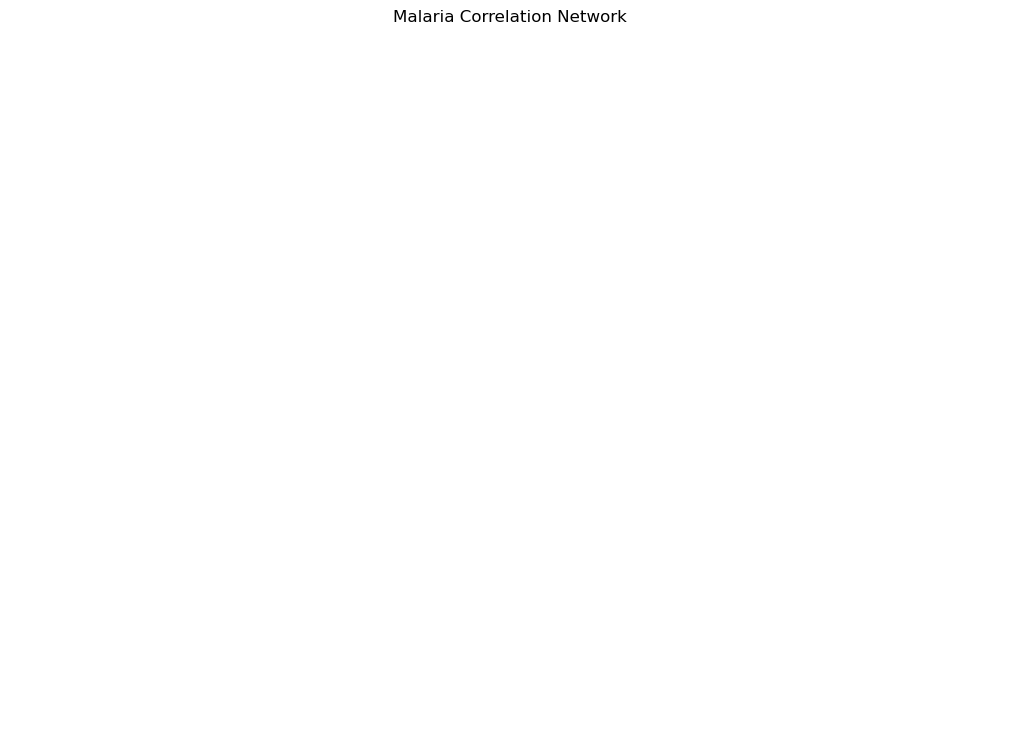

In [32]:
import networkx as nx
import numpy as np

# Compute correlation matrix
corr_matrix = gdf_numeric.corr()

# Filter strong correlations with malaria
malaria_var = "Malaria__2"
strong_corrs = corr_matrix[malaria_var][abs(corr_matrix[malaria_var]) > 0.5].drop(malaria_var)

# Create graph
G = nx.Graph()
for col, weight in strong_corrs.items():
    G.add_edge(malaria_var, col, weight=weight)

# Draw graph
plt.figure(figsize=(10, 7))
pos = nx.spring_layout(G)
nx.draw(G, pos, with_labels=True, node_size=3000, node_color="lightblue", edge_color="gray", font_size=10)
plt.title("Malaria Correlation Network")
plt.show()


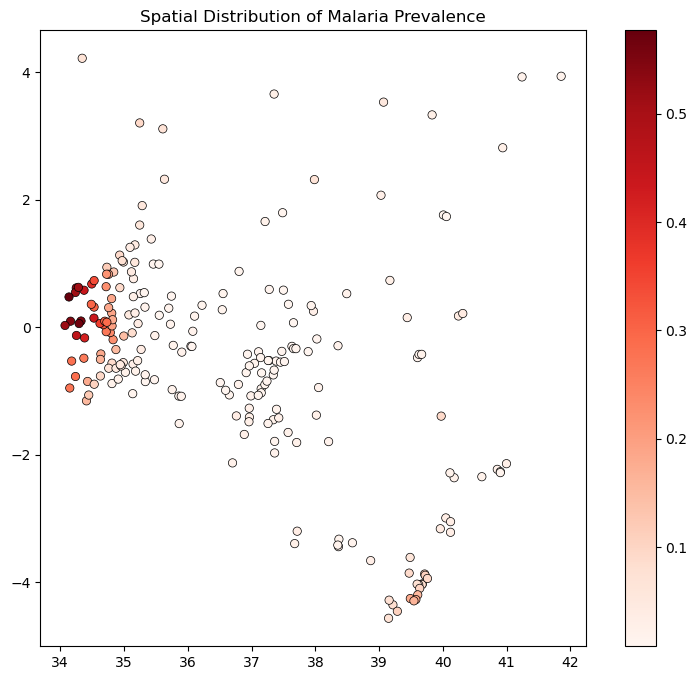

In [33]:
import geopandas as gpd
import matplotlib.pyplot as plt

# Plot malaria prevalence
fig, ax = plt.subplots(figsize=(10, 8))
gdf_2.plot(column="Malaria__2", cmap="Reds", linewidth=0.5, edgecolor="black", legend=True, ax=ax)
ax.set_title("Spatial Distribution of Malaria Prevalence")
plt.show()


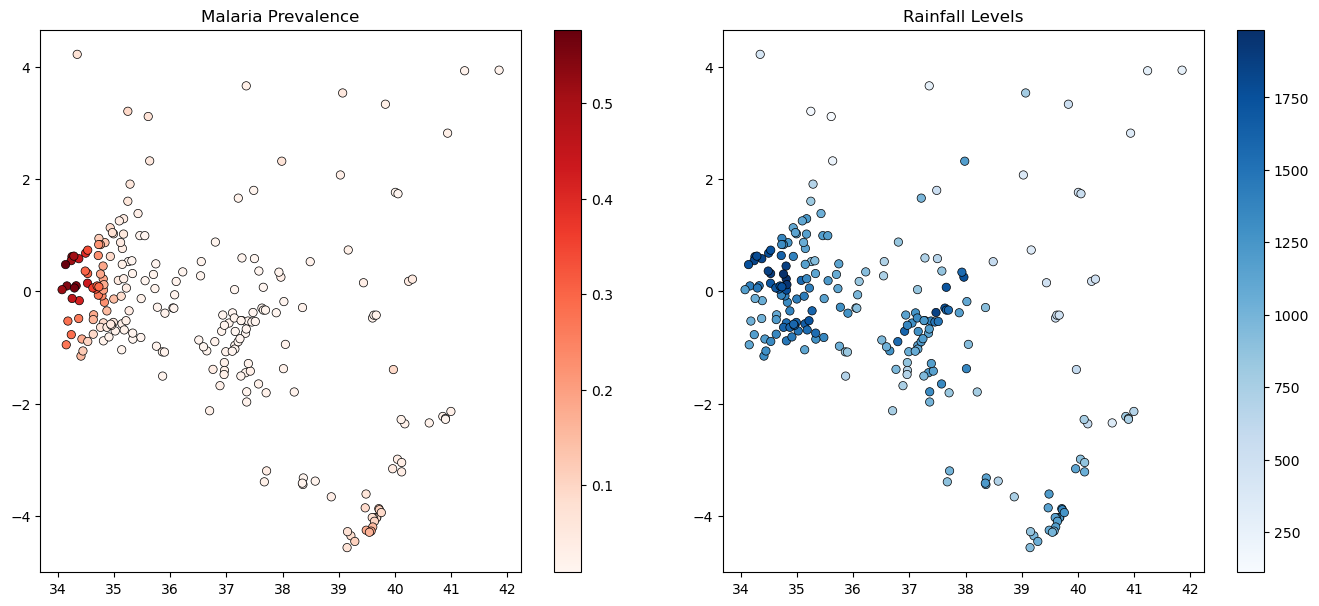

In [34]:
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# Malaria Map
gdf_2.plot(column="Malaria__2", cmap="Reds", linewidth=0.5, edgecolor="black", legend=True, ax=ax[0])
ax[0].set_title("Malaria Prevalence")

# Rainfall Map
gdf_2.plot(column="Rainfall_2", cmap="Blues", linewidth=0.5, edgecolor="black", legend=True, ax=ax[1])
ax[1].set_title("Rainfall Levels")

plt.tight_layout()
plt.show()


In [35]:
from esda.moran import Moran
from libpysal.weights import KNN

# Create spatial weights (using K-Nearest Neighbors)
w = KNN.from_dataframe(gdf_2, k=5)
w.transform = "r"

# Calculate Moran's I
moran = Moran(gdf_2["Malaria__2"], w)
print(f"Moran's I: {moran.I}, p-value: {moran.p_norm}")

# Interpretation:
# - Moran’s I close to +1 → Strong clustering of high/low values.
# - Moran’s I near 0 → Random spatial distribution.
# - Moran’s I close to -1 → High/low values are dispersed.


Moran's I: 0.938275401016183, p-value: 1.2560884821245285e-127


ValueError: The 'url' dict should at least contain a 'url' key

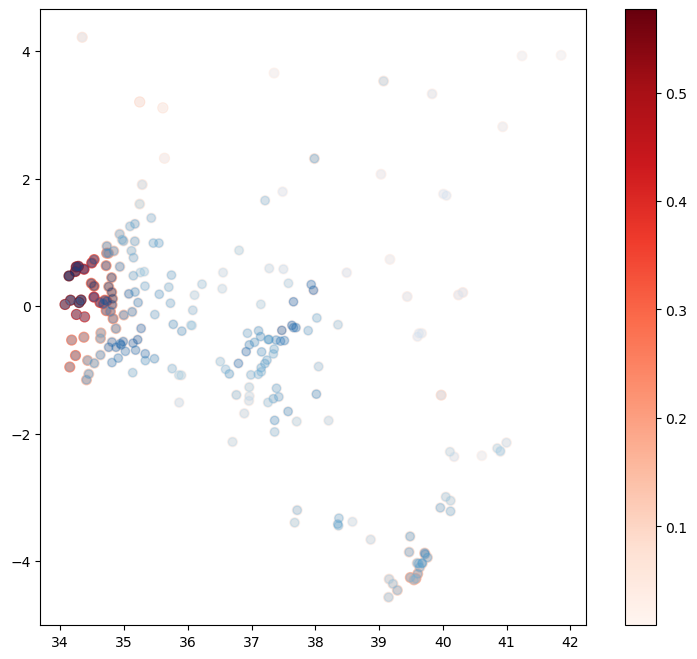

In [37]:
import contextily as ctx

fig, ax = plt.subplots(figsize=(10, 8))
gdf_2.plot(column="Malaria__2", cmap="Reds", alpha=0.7, markersize=50, legend=True, ax=ax)
gdf_2.plot(column="Rainfall_2", cmap="Blues", alpha=0.3, ax=ax)  # Overlay rainfall

ctx.add_basemap(ax, crs=gdf_2.crs, source=ctx.providers.OpenStreetMap)
ax.set_title("Malaria Prevalence vs. Rainfall (Spatial Scatter)")
plt.show()


[[ 4.04761275e-02 -1.60391005e-05 -2.33094332e-04]
 [ 1.34083560e-02 -4.12789149e-08 -2.26380412e-05]
 [ 2.09392746e-02 -4.65668061e-06 -6.28860157e-05]
 [ 1.64368555e-02 -1.87078865e-06 -4.02066567e-05]
 [ 1.47752670e-02 -7.85929546e-07 -2.82734138e-05]
 [ 2.61297541e-02 -7.65909108e-06 -1.02726622e-04]
 [ 1.75090976e-02 -2.61279719e-06 -3.98380164e-05]
 [ 1.64609396e-02 -2.21671766e-06 -1.38235163e-05]
 [ 2.28751592e-02 -5.77007156e-06 -7.80993372e-05]
 [ 1.77266017e-02 -2.72958918e-06 -4.22475351e-05]
 [ 2.69037917e-02 -8.31782204e-06 -1.05244240e-04]
 [ 2.23039964e-02 -5.53687780e-06 -6.80725933e-05]
 [ 3.36978692e-02 -1.25224112e-05 -1.35074396e-04]
 [ 3.56589464e-02 -1.34850073e-05 -1.66558416e-04]
 [ 2.70101553e-02 -8.19001829e-06 -1.14374404e-04]
 [ 3.12877012e-02 -1.12881872e-05 -9.72217316e-05]
 [ 3.39518253e-02 -1.33022793e-05 -1.08957238e-04]
 [ 4.05975747e-02 -1.54496480e-05 -2.98814968e-04]
 [ 3.46392039e-02 -1.26469826e-05 -2.04066822e-04]
 [ 3.63023358e-02 -1.39743052e-

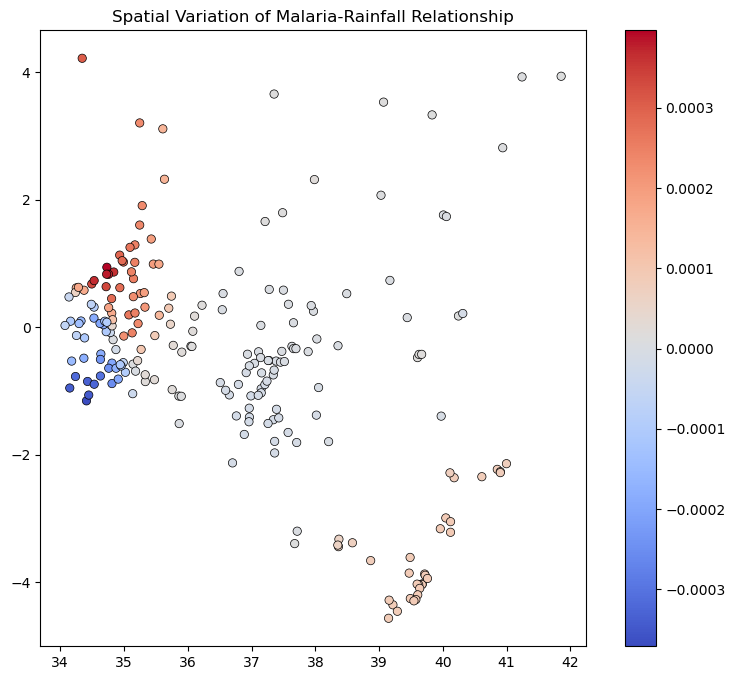

In [38]:
from mgwr.gwr import GWR
from mgwr.sel_bw import Sel_BW
import numpy as np

# Prepare variables (example: malaria vs. rainfall & temperature)
y = gdf_2[["Malaria__2"]].values
X = gdf_2[["Rainfall_2", "Mean_Tem_2"]].values
coords = np.column_stack([gdf_2.geometry.x, gdf_2.geometry.y])

# Select bandwidth for GWR
bw = Sel_BW(coords, y, X).search()

# Run GWR model
model = GWR(coords, y, X, bw)
results = model.fit()

# Print spatially varying coefficients
print(results.params)

# Visualize spatial variations
gdf_2["GWR_Rainfall_Coeff"] = results.params[:, 1]

# Plot spatial variation of the relationship
fig, ax = plt.subplots(figsize=(10, 8))
gdf_2.plot(column="GWR_Rainfall_Coeff", cmap="coolwarm", linewidth=0.5, edgecolor="black", legend=True, ax=ax)
ax.set_title("Spatial Variation of Malaria-Rainfall Relationship")
plt.show()
